<a href="https://colab.research.google.com/github/Sanskar-cpu-sudo/Deep-Learning/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Implement transfer learning for Cats vs Dogs image classification using AlexNet, VGG16, ResNet50, and EfficientNetB0.
# Train and evaluate the models, then compare their accuracy, loss, and training performance.

import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kaggle

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_c8d9649986fd5045e7ed7221ba06845e"

In [ ]:
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [ ]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100% 218M/218M [00:11<00:00, 20.3MB/s]



In [ ]:
!ls -lh


total 218M
-rw-r--r-- 1 root root 218M Sep 30  2019 cat-and-dog.zip
drwxr-xr-x 1 root root 4.0K Aug 24 13:28 sample_data


In [ ]:
import zipfile

with zipfile.ZipFile("cat-and-dog.zip", "r") as zip_ref:
    zip_ref.extractall("cats_dogs")

print("Dataset extracted!")

Dataset extracted!


In [ ]:
!find cats_dogs -maxdepth 3 -type d

cats_dogs
cats_dogs/test_set
cats_dogs/test_set/test_set
cats_dogs/test_set/test_set/cats
cats_dogs/test_set/test_set/dogs
cats_dogs/training_set
cats_dogs/training_set/training_set
cats_dogs/training_set/training_set/cats
cats_dogs/training_set/training_set/dogs


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_path = "cats_dogs/training_set/training_set"
test_path = "cats_dogs/test_set/test_set"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Classes:", train_ds.class_names)

Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Found 2023 files belonging to 2 classes.
Classes: ['cats', 'dogs']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

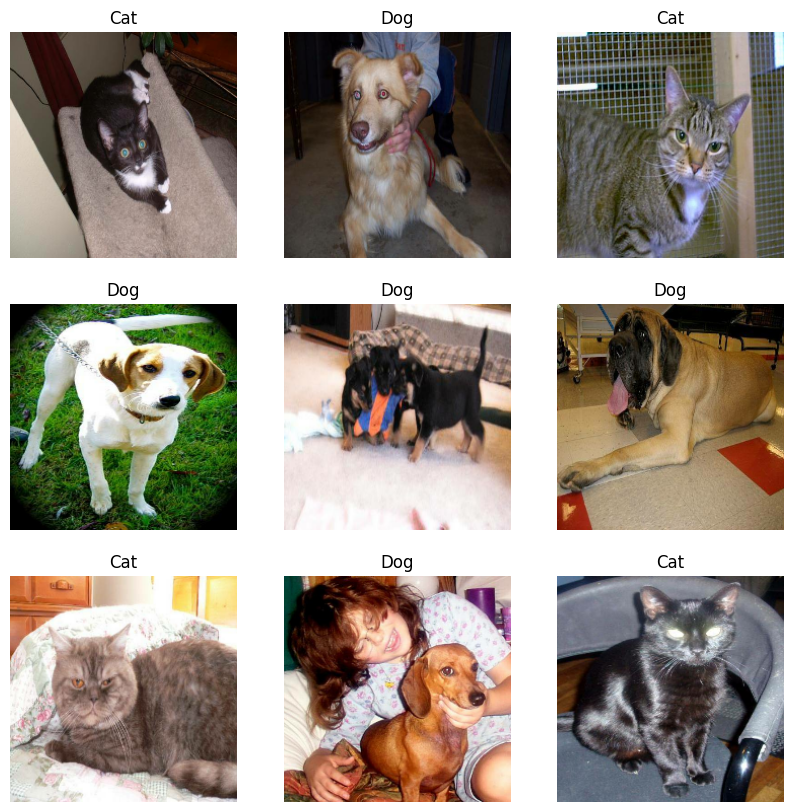

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        if labels[i].numpy() == 0:
            plt.title("Cat")
        else:
            plt.title("Dog")

        plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models

In [ ]:
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

vgg_base.trainable = False

print("VGG16 loaded successfully")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16 loaded successfully


In [ ]:
vgg_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

    layers.Lambda(preprocess_input),

    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [ ]:
vgg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
vgg_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
import time

start = time.time()

vgg_history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

vgg_time = time.time() - start

print("VGG16 training time:", vgg_time, "seconds")

Epoch 1/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - accuracy: 0.8182 - loss: 0.7260 - val_accuracy: 0.9663 - val_loss: 0.1153
Epoch 2/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.9243 - loss: 0.2449 - val_accuracy: 0.9744 - val_loss: 0.0915
Epoch 3/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 44s 190ms/step - accuracy: 0.9472 - loss: 0.1704 - val_accuracy: 0.9769 - val_loss: 0.0765
VGG16 training time: 121.87899017333984 seconds


In [ ]:
vgg_loss, vgg_accuracy = vgg_model.evaluate(
    test_ds,
    verbose=1
)

print("VGG16 Test Accuracy:", vgg_accuracy)
print("VGG16 Test Loss:", vgg_loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9797 - loss: 0.0799
VGG16 Test Accuracy: 0.9797330498695374
VGG16 Test Loss: 0.079856738448143


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

print("ResNet50 loaded successfully")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 loaded successfully


In [ ]:
resnet_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

    layers.Lambda(preprocess_input),

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [ ]:
resnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
start = time.time()

resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

resnet_time = time.time() - start

print("ResNet50 training time:", resnet_time, "seconds")

Epoch 1/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 45s 185ms/step - accuracy: 0.9485 - loss: 0.1320 - val_accuracy: 0.9856 - val_loss: 0.0441
Epoch 2/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 167ms/step - accuracy: 0.9799 - loss: 0.0594 - val_accuracy: 0.9881 - val_loss: 0.0360
Epoch 3/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 168ms/step - accuracy: 0.9809 - loss: 0.0510 - val_accuracy: 0.9881 - val_loss: 0.0341
ResNet50 training time: 119.64738130569458 seconds


In [ ]:
resnet_loss, resnet_accuracy = resnet_model.evaluate(
    test_ds,
    verbose=1
)

print("ResNet50 Test Accuracy:", resnet_accuracy)
print("ResNet50 Test Loss:", resnet_loss)


64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.9891 - loss: 0.0347
ResNet50 Test Accuracy: 0.9891250729560852
ResNet50 Test Loss: 0.03472614660859108


In [ ]:
from tensorflow.keras.applications import EfficientNetB0

In [ ]:
efficientnet_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

efficientnet_base.trainable = False

print("EfficientNetB0 loaded successfully")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0 loaded successfully


In [ ]:
efficientnet_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

    efficientnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [ ]:
efficientnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
efficientnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
start = time.time()

efficientnet_history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

efficientnet_time = time.time() - start

print(
    "EfficientNetB0 training time:",
    efficientnet_time,
    "seconds"
)

Epoch 1/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.9592 - loss: 0.1558 - val_accuracy: 0.9913 - val_loss: 0.0466
Epoch 2/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.9774 - loss: 0.0669 - val_accuracy: 0.9938 - val_loss: 0.0310
Epoch 3/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.9809 - loss: 0.0561 - val_accuracy: 0.9950 - val_loss: 0.0251
EfficientNetB0 training time: 94.39384698867798 seconds


In [ ]:
efficientnet_loss, efficientnet_accuracy = efficientnet_model.evaluate(
    test_ds,verbose=1
)
print(
    "EfficientNetB0 Test Accuracy:",
    efficientnet_accuracy
)

print(
    "EfficientNetB0 Test Loss:",
    efficientnet_loss
)

64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.9916 - loss: 0.0303
EfficientNetB0 Test Accuracy: 0.9915966391563416
EfficientNetB0 Test Loss: 0.030268054455518723


In [ ]:
def create_alexnet():

    model = models.Sequential([

        layers.Input(shape=(224, 224, 3)),

        # Data augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        # Normalize pixels
        layers.Rescaling(1.0 / 255),

        # Conv Layer 1
        layers.Conv2D(
            96,
            kernel_size=11,
            strides=4,
            activation="relu"
        ),

        layers.MaxPooling2D(
            pool_size=3,
            strides=2
        ),

        # Conv Layer 2
        layers.Conv2D(
            256,
            kernel_size=5,
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            pool_size=3,
            strides=2
        ),

        # Conv Layer 3
        layers.Conv2D(
            384,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        # Conv Layer 4
        layers.Conv2D(
            384,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        # Conv Layer 5
        layers.Conv2D(
            256,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            pool_size=3,
            strides=2
        ),

        # Flatten
        layers.Flatten(),

        # Fully Connected Layer 1
        layers.Dense(
            4096,
            activation="relu"
        ),

        layers.Dropout(0.5),

        # Fully Connected Layer 2
        layers.Dense(
            4096,
            activation="relu"
        ),

        layers.Dropout(0.5),

        # Output
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model

In [ ]:
alexnet_model = create_alexnet()

print("AlexNet created successfully!")

AlexNet created successfully!


In [ ]:
alexnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
alexnet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,751,105 (178.34 MB)

 Trainable params: 46,751,105 (178.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

alexnet_history = alexnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

alexnet_time = time.time() - start

print(
    "AlexNet training time:",
    alexnet_time,
    "seconds"
)

Epoch 1/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.5173 - loss: 0.6942 - val_accuracy: 0.5122 - val_loss: 0.6926
Epoch 2/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.5270 - loss: 0.6892 - val_accuracy: 0.4978 - val_loss: 0.7024
Epoch 3/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.5832 - loss: 0.6713 - val_accuracy: 0.6327 - val_loss: 0.6410
AlexNet training time: 47.91803526878357 seconds


In [ ]:
alexnet_loss, alexnet_accuracy = alexnet_model.evaluate(
    test_ds,
    verbose=1
)

print("AlexNet Test Accuracy:", alexnet_accuracy)
print("AlexNet Test Loss:", alexnet_loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6446 - loss: 0.6432
AlexNet Test Accuracy: 0.6445872187614441
AlexNet Test Loss: 0.6432492733001709


In [ ]:
import pandas as pd

results = pd.DataFrame({

    "Model": [
        "AlexNet",
        "VGG16",
        "ResNet50",
        "EfficientNetB0"
    ],

    "Accuracy": [
        alexnet_accuracy,
        vgg_accuracy,
        resnet_accuracy,
        efficientnet_accuracy
    ],

    "Loss": [
        alexnet_loss,
        vgg_loss,
        resnet_loss,
        efficientnet_loss
    ],

    "Training Time (seconds)": [
        alexnet_time,
        vgg_time,
        resnet_time,
        efficientnet_time
    ]
})

print(results)

            Model  Accuracy      Loss  Training Time (seconds)
0         AlexNet  0.644587  0.643249                47.918035
1           VGG16  0.979733  0.079857               121.878990
2        ResNet50  0.989125  0.034726               119.647381
3  EfficientNetB0  0.991597  0.030268                94.393847


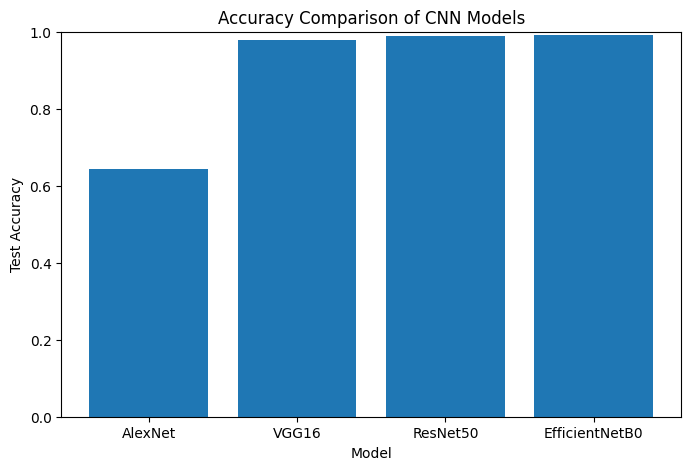

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Accuracy Comparison of CNN Models")

plt.xlabel("Model")

plt.ylabel("Test Accuracy")

plt.ylim(0, 1)

plt.show()